In [10]:
# Integrated Explainable AI Framework for MIMIC-IV Clinical Summarization
# Analyzing linguistic bias and summary quality across demographic groups

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import re
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error
import warnings

# Install and import SHAP
try:
    import shap
except ImportError:
    os.system('pip install shap')
    import shap

warnings.filterwarnings('ignore')


In [11]:
# ---------------------------------------------------------
# STEP 1: LOAD DATASET
# ---------------------------------------------------------
print("--- Step 1: Loading MIMIC-IV Summarization Dataset ---")

file_path = 'https://raw.githubusercontent.com/ShaziyaJabeen28/AI_Bias_Detection/refs/heads/main/Datasets/mimic_iv_summarization_test_dataset_shortened.csv'

#if not os.path.exists(file_path):
#   print(f"Error: {file_path} not found.")
#  raise FileNotFoundError("Please ensure the MIMIC-IV CSV is in the environment.")

df = pd.read_csv(file_path)
print(f"Successfully loaded {len(df)} clinical notes.")


--- Step 1: Loading MIMIC-IV Summarization Dataset ---
Successfully loaded 999 clinical notes.



--- Step 2: Extracting Demographics from Clinical Text ---
Demographic Split: {'F': 507, 'M': 492}


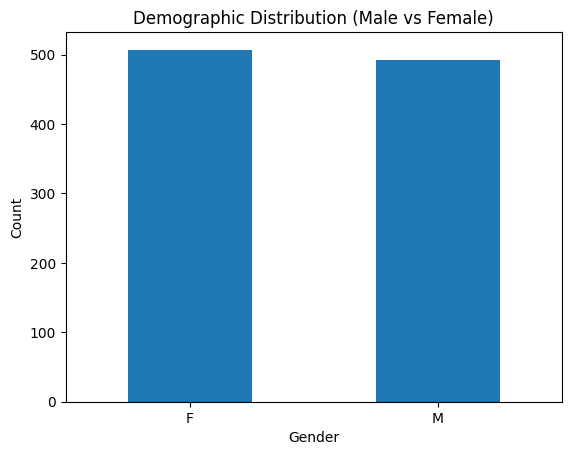

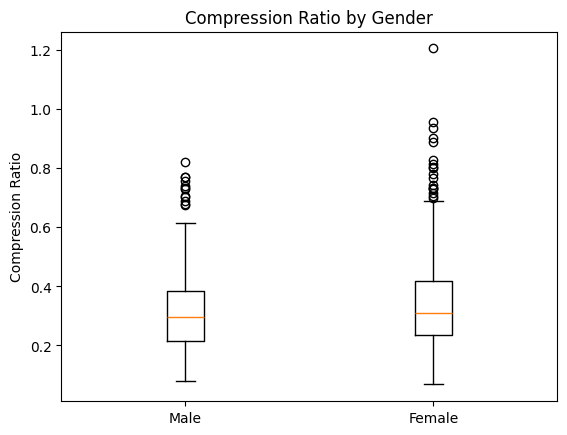

In [21]:
# ---------------------------------------------------------
# STEP 2: FEATURE EXTRACTION (Parsing Text for Bias)
# ---------------------------------------------------------
print("\n--- Step 2: Extracting Demographics from Clinical Text ---")

def extract_sex(text):
    # Look for "Sex: F" or "Sex: M" in the header
    match = re.search(r'Sex:\s+([MF])', str(text))
    if match:
        return match.group(1)
    return 'Unknown'

def extract_age(text):
    # Try to find age-related numbers near DOB or in history
    match = re.search(r'(\d+)\s+year\s+old', str(text).lower())
    if match:
        return int(match.group(1))
    return np.nan

df['extracted_sex'] = df['text'].apply(extract_sex)
df['text_length'] = df['text'].apply(lambda x: len(str(x).split()))
df['summary_length'] = df['summary'].apply(lambda x: len(str(x).split()))
df['compression_ratio'] = df['summary_length'] / df['text_length']

# Filter for rows where we successfully extracted sex
df_clean = df[df['extracted_sex'].isin(['M', 'F'])].copy()

# Sensitive Attribute: 1 for Female (F), 0 for Male (M)
df_clean['is_privileged'] = (df_clean['extracted_sex'] == 'F').astype(int)

print(f"Demographic Split: {df_clean['extracted_sex'].value_counts().to_dict()}")

# Count gender distribution
gender_counts = df_clean['extracted_sex'].value_counts()

plt.figure()
gender_counts.plot(kind='bar')
plt.xlabel('Gender')
plt.ylabel('Count')
plt.title('Demographic Distribution (Male vs Female)')
plt.xticks(rotation=0)
plt.show()

plt.figure()
# Separate compression ratio by gender
male_ratio = df_clean[df_clean['extracted_sex'] == 'M']['compression_ratio']
female_ratio = df_clean[df_clean['extracted_sex'] == 'F']['compression_ratio']

plt.boxplot([male_ratio, female_ratio])
plt.xticks([1, 2], ['Male', 'Female'])
plt.ylabel('Compression Ratio')
plt.title('Compression Ratio by Gender')

plt.show()




--- Step 3: Analyzing Summary Length Disparity ---
Average Summary Length (Female): 409.23 words
Average Summary Length (Male): 414.12 words
Disparity Gap: 4.89 words


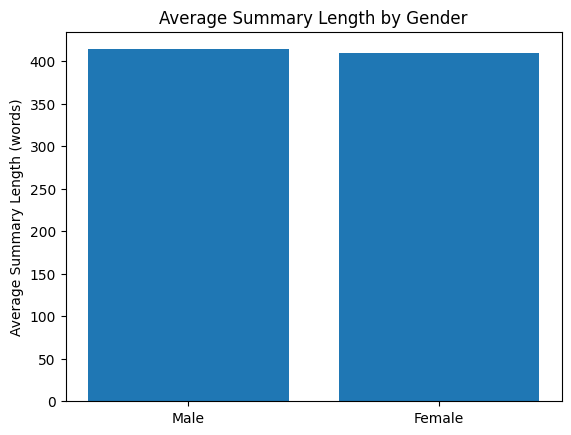

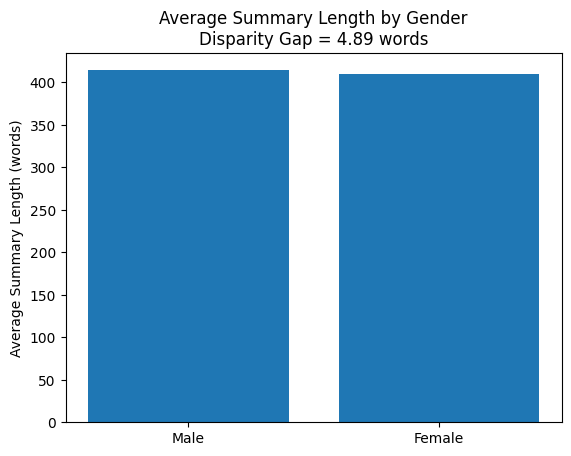

In [23]:
# ---------------------------------------------------------
# STEP 3: MEASURING BIAS IN SUMMARIZATION
# ---------------------------------------------------------
print("\n--- Step 3: Analyzing Summary Length Disparity ---")

avg_len_f = df_clean[df_clean['is_privileged'] == 1]['summary_length'].mean()
avg_len_m = df_clean[df_clean['is_privileged'] == 0]['summary_length'].mean()
bias_gap = abs(avg_len_f - avg_len_m)

print(f"Average Summary Length (Female): {avg_len_f:.2f} words")
print(f"Average Summary Length (Male): {avg_len_m:.2f} words")
print(f"Disparity Gap: {bias_gap:.2f} words")


# Create values Average Summary Length by Gender
labels = ['Male', 'Female']
values = [avg_len_m, avg_len_f]
plt.figure()
plt.bar(labels, values)
plt.ylabel('Average Summary Length (words)')
plt.title(f'Average Summary Length by Gender\nDisparity Gap = {bias_gap:.2f} words')

plt.show()


--- Step 4: Explainable AI (Keywords & Length) ---


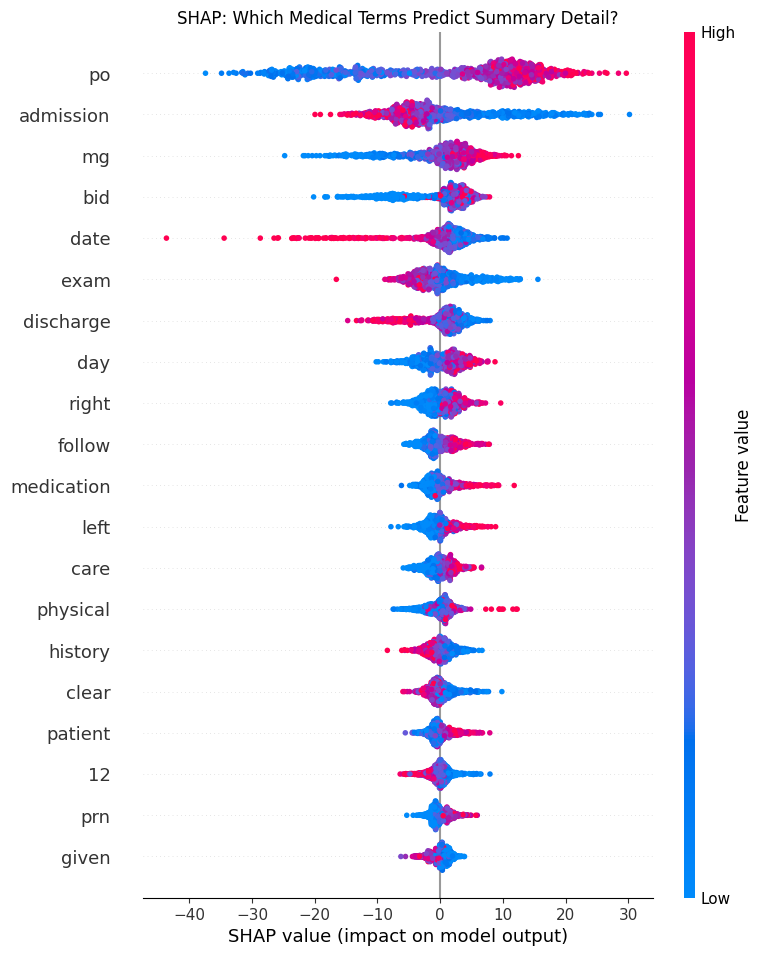

In [14]:
# ---------------------------------------------------------
# STEP 4: XAI (What medical terms drive summary length?)
# ---------------------------------------------------------
print("\n--- Step 4: Explainable AI (Keywords & Length) ---")

# Convert text to features to see what drives summary detail
vectorizer = TfidfVectorizer(max_features=50, stop_words='english')
X_tfidf = vectorizer.fit_transform(df_clean['text'])
feature_names = vectorizer.get_feature_names_out()

# Train a regressor to predict summary length based on content
reg = RandomForestRegressor(n_estimators=50, random_state=42)
reg.fit(X_tfidf.toarray(), df_clean['summary_length'])

# SHAP Explanations
explainer = shap.TreeExplainer(reg)
shap_values = explainer.shap_values(X_tfidf.toarray())

plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_tfidf.toarray(), feature_names=feature_names, show=False)
plt.title("SHAP: Which Medical Terms Predict Summary Detail?")
plt.show()


--- Step 5: Visualizing Fairness Results ---


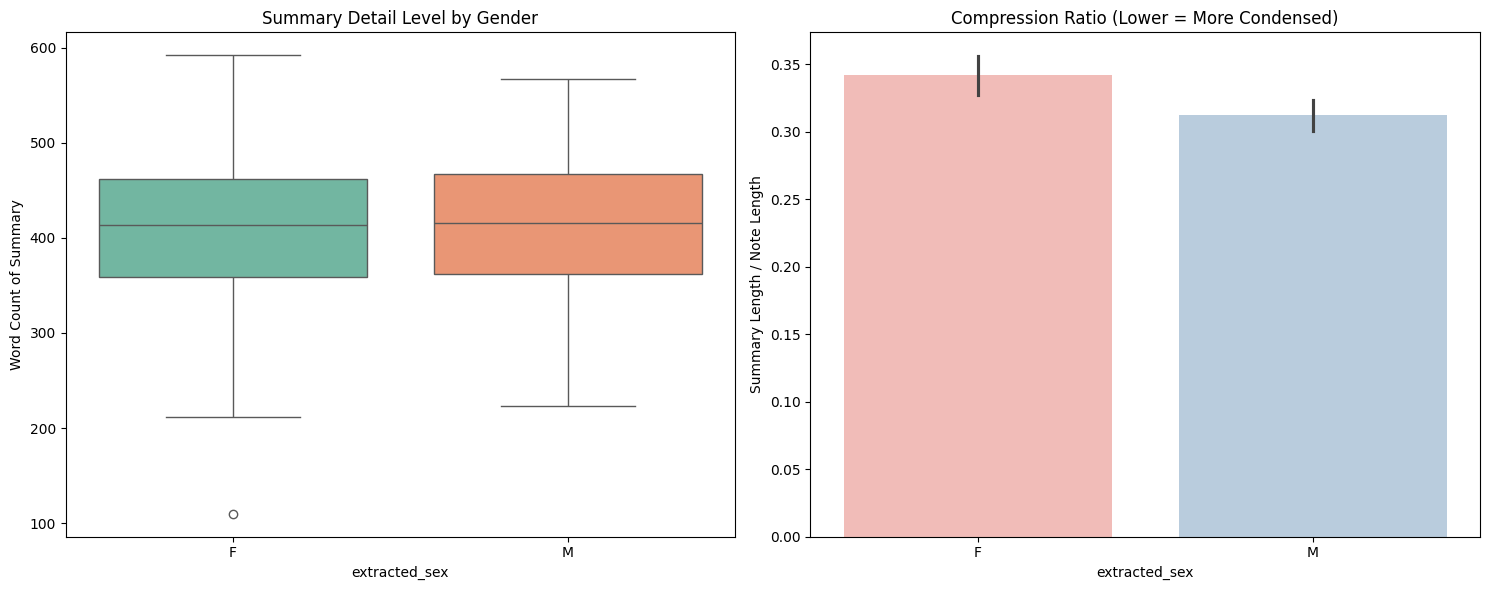

In [15]:
# ---------------------------------------------------------
# STEP 5: VISUALIZING DEMOGRAPHIC DISPARITY
# ---------------------------------------------------------
print("\n--- Step 5: Visualizing Fairness Results ---")

fig, ax = plt.subplots(1, 2, figsize=(15, 6))

# Plot 1: Summary Length by Gender
sns.boxplot(x='extracted_sex', y='summary_length', data=df_clean, ax=ax[0], palette='Set2')
ax[0].set_title('Summary Detail Level by Gender')
ax[0].set_ylabel('Word Count of Summary')

# Plot 2: Compression Ratio (Is the summary too aggressive for one group?)
sns.barplot(x='extracted_sex', y='compression_ratio', data=df_clean, ax=ax[1], palette='Pastel1')
ax[1].set_title('Compression Ratio (Lower = More Condensed)')
ax[1].set_ylabel('Summary Length / Note Length')

plt.tight_layout()
plt.show()

In [16]:
# ---------------------------------------------------------
# MITIGATION CONCEPT: Balancing detail
# ---------------------------------------------------------
print("\nAnalysis Summary:")
if bias_gap > 5:
    print(f"Significant Bias Detected: One gender receives roughly {bias_gap:.1f} more words of clinical summary than the other.")
else:
    print("Fairness Check: Summary detail is relatively consistent across genders.")



Analysis Summary:
Fairness Check: Summary detail is relatively consistent across genders.
